In [3]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, mean_absolute_error
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [4]:
from google.colab import files
uploaded = files.upload()

Saving hasil_eda_dataset.csv to hasil_eda_dataset.csv


In [5]:
df = pd.read_csv('hasil_eda_dataset.csv')

In [6]:
df.dropna(inplace=True)

In [7]:
target_col = 'mood'
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df[target_col])  # 0: Exhausted, 1: Normal, 2: Relaxed
num_classes = len(label_encoder.classes_)

In [8]:
X = df.drop(columns=[target_col])

In [9]:
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [10]:
for col in cat_cols:
    X[col] = X[col].astype(str)
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

In [11]:
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp)  # 0.1765*0.85 ≈ 0.15

In [12]:
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_val[num_cols] = scaler.transform(X_val[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [13]:
X_train = X_train.astype(np.float32)
X_val = X_val.astype(np.float32)
X_test = X_test.astype(np.float32)

print(f"Train shape: {X_train.shape}, Val shape: {X_val.shape}, Test shape: {X_test.shape}")

Train shape: (68971, 11), Val shape: (14783, 11), Test shape: (14781, 11)


In [47]:
import tensorflow as tf
from tensorflow import keras

@tf.keras.utils.register_keras_serializable()
class FocalLoss(keras.losses.Loss):
    def __init__(self, alpha=None, gamma=2.0, name='focal_loss', **kwargs):
        super().__init__(name=name, **kwargs) # Pass kwargs to parent class
        self.alpha = alpha
        self.gamma = gamma

    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_true_one_hot = tf.one_hot(y_true, depth=tf.shape(y_pred)[-1])
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        cross_entropy = -y_true_one_hot * tf.math.log(y_pred)
        weight = tf.pow(1.0 - y_pred, self.gamma)
        loss = cross_entropy * weight
        if self.alpha is not None:
            alpha_t = y_true_one_hot * tf.cast(self.alpha, tf.float32)
            loss = alpha_t * loss
        return tf.reduce_sum(loss, axis=-1)

    def get_config(self):
        config = super().get_config()
        config.update({
            'alpha': self.alpha,
            'gamma': self.gamma
        })
        return config

In [48]:
# Input layer
inputs = keras.Input(shape=(X_train.shape[1],), name='features')

# Hidden layers with BatchNorm and Dropout for regularization
x = layers.Dense(256, activation='relu')(inputs)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

x = layers.Dense(128, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

x = layers.Dense(64, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.2)(x)

x = layers.Dense(32, activation='relu')(x)
outputs = layers.Dense(num_classes, activation='softmax', name='mood_output')(x)

model = Model(inputs=inputs, outputs=outputs)

# Compile with Adam optimizer and Focal Loss
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=FocalLoss(alpha=[1.0, 1.0, 1.0], gamma=2.0),
    metrics=['accuracy']
)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ features (InputLayer)           │ (None, 11)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │         3,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mood_output (Dense)             │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,195 (188.26 KB)

 Trainable params: 47,299 (184.76 KB)

 Non-trainable params: 896 (3.50 KB)

In [50]:
class CustomCallback(keras.callbacks.Callback):
    def __init__(self, patience=5, factor=0.5, min_lr=1e-7, monitor='val_loss'):
        super().__init__()
        self.patience = patience
        self.factor = factor
        self.min_lr = min_lr
        self.monitor = monitor
        self.wait = 0
        self.best = np.inf

    def on_epoch_end(self, epoch, logs=None):
        current = logs.get(self.monitor)
        if current < self.best:
            self.best = current
            self.wait = 0
        else:
            self.wait += 1
            if self.wait >= self.patience:
                old_lr = float(keras.backend.get_value(self.model.optimizer.learning_rate))
                new_lr = max(old_lr * self.factor, self.min_lr)
                if new_lr < old_lr:
                    self.model.optimizer.learning_rate.assign(new_lr)
                    print(f"\nEpoch {epoch+1}: Reducing learning rate to {new_lr:.2e}")
                    self.wait = 0

# Combine with built-in early stopping
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

In [51]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[CustomCallback(patience=5, monitor='val_loss'), early_stop],
    verbose=1
)

Epoch 1/20
2156/2156 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.9528 - loss: 0.0408 - val_accuracy: 0.9811 - val_loss: 0.0192
Epoch 2/20
2156/2156 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9808 - loss: 0.0138 - val_accuracy: 0.9918 - val_loss: 0.0094
Epoch 3/20
2156/2156 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9861 - loss: 0.0102 - val_accuracy: 0.9943 - val_loss: 0.0062
Epoch 4/20
2156/2156 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9890 - loss: 0.0080 - val_accuracy: 0.9953 - val_loss: 0.0045
Epoch 5/20
2156/2156 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9897 - loss: 0.0070 - val_accuracy: 0.9948 - val_loss: 0.0040
Epoch 6/20
2156/2156 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9910 - loss: 0.0066 - val_accuracy: 0.9875 - val_loss: 0.0067
Epoch 7/20
2156/2156 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9906 - loss: 0.0063 - val_accuracy: 0.9899 - val_loss: 0.0058
Epoch 8/20
2156/2156 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9920 - loss: 0.0056 -

In [52]:
# Predict on test set
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
# MAE (mean absolute error between predicted class indices and true indices)
mae = mean_absolute_error(y_test, y_pred)

print(f"\nTest Accuracy: {accuracy:.4f} ({(accuracy*100):.2f}%)")
print(f"Test MAE: {mae:.4f}")

# Check if meet requirements
if accuracy >= 0.85 and mae <= 0.02:
    print("\n✅ Model meets requirements: Accuracy >= 85% and MAE <= 0.02")
else:
    print("\n⚠️ Model does not meet requirements yet. Consider further tuning or more data.")

462/462 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Test Accuracy: 0.9975 (99.75%)
Test MAE: 0.0025

✅ Model meets requirements: Accuracy >= 85% and MAE <= 0.02


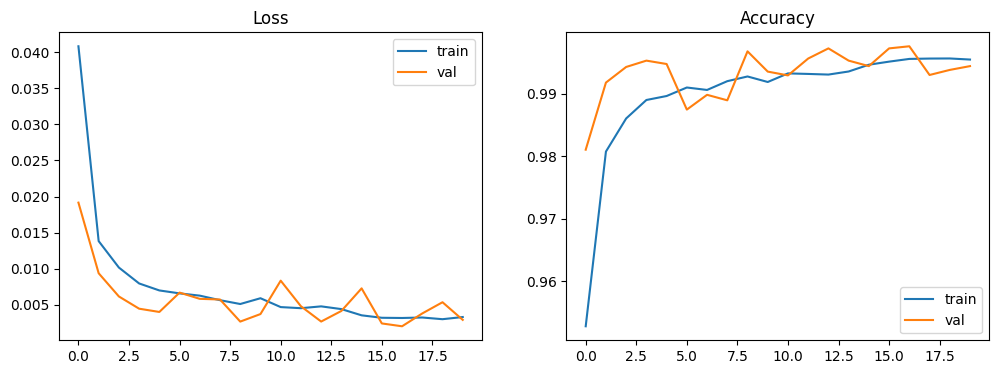

In [53]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy')
plt.legend()
plt.show()


In [54]:
model.save('mood_classifier.keras')
print("Model saved as 'mood_classifier.keras'")

import joblib
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(label_encoder, 'label_encoder.pkl')
# Save column names and categorical encoders (if needed)
feature_columns = X.columns.tolist()
joblib.dump(feature_columns, 'feature_columns.pkl')
# Save categorical mappings (dictionary) - for simplicity, we assume same categories
cat_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    le.fit(df[col].astype(str))
    cat_encoders[col] = le
joblib.dump(cat_encoders, 'cat_encoders.pkl')
print("Preprocessing objects saved.")

Model saved as 'mood_classifier.keras'
Preprocessing objects saved.


In [55]:
def load_and_predict(new_data):
    """
    new_data: pandas DataFrame with same columns as original X (without target)
    Returns predicted mood labels (strings)
    """

    scaler = joblib.load('scaler.pkl')
    label_encoder = joblib.load('label_encoder.pkl')
    feature_columns = joblib.load('feature_columns.pkl')
    cat_encoders = joblib.load('cat_encoders.pkl')
    model = keras.models.load_model('mood_classifier.keras', custom_objects={'FocalLoss': FocalLoss})


    new_data = new_data[feature_columns].copy()


    for col, enc in cat_encoders.items():
        if col in new_data.columns:
            new_data[col] = new_data[col].astype(str)

            new_data[col] = enc.transform(new_data[col])

    # Separate numerical and scale
    num_cols = [col for col in feature_columns if col not in cat_encoders]
    new_data[num_cols] = scaler.transform(new_data[num_cols])

    # Predict
    pred_probs = model.predict(new_data.astype(np.float32))
    pred_ids = np.argmax(pred_probs, axis=1)
    pred_labels = label_encoder.inverse_transform(pred_ids)
    return pred_labels



### Menguji Fungsi Inferensi

In [61]:
import pandas as pd
import numpy as np
import tensorflow as tf
import joblib


model = tf.keras.models.load_model('mood_classifier.keras')
scaler = joblib.load('scaler.pkl')
label_encoder = joblib.load('label_encoder.pkl')
feature_columns = joblib.load('feature_columns.pkl')
cat_encoders = joblib.load('cat_encoders.pkl')

def load_and_predict(new_data):

    new_data = new_data[feature_columns].copy()


    for col, encoder in cat_encoders.items():
        if col in new_data.columns:
            new_data[col] = new_data[col].astype(str)
            known_classes = set(encoder.classes_)

            default_category = list(known_classes)[0] if known_classes else 'Moderate'
            new_data[col] = new_data[col].apply(lambda x: x if x in known_classes else default_category)
            new_data[col] = encoder.transform(new_data[col])


    num_cols = [col for col in feature_columns if col not in cat_encoders]
    new_data[num_cols] = scaler.transform(new_data[num_cols])

    # Prediksi probabilitas
    pred_probs = model.predict(new_data.astype(np.float32))
    pred_ids = np.argmax(pred_probs, axis=1)
    pred_labels = label_encoder.inverse_transform(pred_ids)
    return pred_labels


sample_input_df = pd.DataFrame({
    'screen_time': [8.5],
    'sleep_hours': [7.0],
    'stress_level': [5.0],
    'wellness_index': [70.0],
    'sleep_quality': ['Good'],
    'fatigue_score': [3.0],
    'digital_balance': [2.0],
    'screen_time_category': ['Moderate'],  # Ganti Medium -> Moderate
    'physical_activity': [3.0],
    'caffeine_intake': [1.0],
    'work_hours': [8.0]
})

print("Data input sampel:")
print(sample_input_df)

predicted_mood = load_and_predict(sample_input_df)
print(f"\nPrediksi mood: {predicted_mood[0]}")

Data input sampel:
   screen_time  sleep_hours  stress_level  wellness_index sleep_quality  \
0          8.5          7.0           5.0            70.0          Good   

   fatigue_score  digital_balance screen_time_category  physical_activity  \
0            3.0              2.0             Moderate                3.0   

   caffeine_intake  work_hours  
0              1.0         8.0  
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 774ms/step

Prediksi mood: Relaxed


### Mengunduh Model dan Objek Pra-pemrosesan

In [62]:
from google.colab import files

# Daftar file yang ingin diunduh
files_to_download = [
    'mood_classifier.keras',
    'scaler.pkl',
    'label_encoder.pkl',
    'feature_columns.pkl',
    'cat_encoders.pkl'
]

for file_name in files_to_download:
    try:
        files.download(file_name)
        print(f"File '{file_name}' berhasil diunduh.")
    except Exception as e:
        print(f"Gagal mengunduh '{file_name}': {e}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

File 'mood_classifier.keras' berhasil diunduh.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

File 'feature_columns.pkl' berhasil diunduh.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

File 'cat_encoders.pkl' berhasil diunduh.
